In [4]:
!python -V

Python 3.10.16


In [5]:
import pandas as pd

In [6]:
import pickle

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.metrics import root_mean_squared_error

In [9]:
import mlflow
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("nyc-taxi-experiment")

<Experiment: artifact_location='/workspaces/mlops-zoomcamp/02-experiment-tracking/mlruns/1', creation_time=1747982557704, experiment_id='1', last_update_time=1747982557704, lifecycle_stage='active', name='nyc-taxi-experiment', tags={}>

In [10]:
df = pd.read_parquet('./data/green_tripdata_2023-01.parquet')

df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

df = df[(df.duration >= 1) & (df.duration <= 60)]

categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

df[categorical] = df[categorical].astype(str)

In [11]:
train_dicts = df[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

target = 'duration'
y_train = df[target].values

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)

root_mean_squared_error(y_train, y_pred)

7.060351539677301

/tmp/ipykernel_2640/1672306066.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label='prediction')
/tmp/ipykernel_2640/1672306066.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train, label='actual')


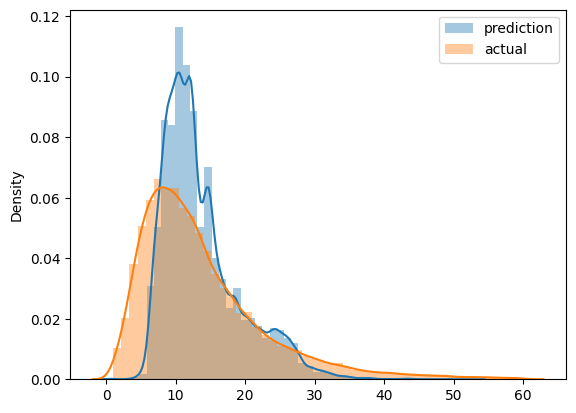

In [12]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label='actual')

plt.legend()

In [13]:
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)

        df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
        df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df

In [14]:
df_train = read_dataframe('./data/green_tripdata_2023-01.parquet')
df_val = read_dataframe('./data/green_tripdata_2023-02.parquet')

In [15]:
len(df_train), len(df_val)

(65946, 62574)

In [16]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [17]:
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [18]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [19]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

6.037135919676125

In [20]:
with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

In [21]:
with mlflow.start_run():

    mlflow.set_tag("developer", "mzt")
    mlflow.log_param("train-data-path", './data/green_tripdata_2023-01.parquet')
    mlflow.log_param("valid-data-path", './data/green_tripdata_2023-02.parquet')    

    alpha = 0.01
    mlflow.log_param("alpha", alpha)

    lr = Lasso(alpha)
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_val)

    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse", rmse)

In [22]:
mlflow.get_tracking_uri()

'sqlite:///mlflow.db'

In [23]:
import xgboost as xgb

from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

In [24]:
train = xgb.DMatrix(X_train, label=y_train)
valid = xgb.DMatrix(X_val, label=y_val)

In [26]:
def objective(params):
    with mlflow.start_run():
        mlflow.set_tag("model", "xgboost")
        mlflow.log_params(params)
        booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=1000,
            evals=[(valid, 'validation')],
            early_stopping_rounds=50
        )
        y_pred = booster.predict(valid)
        rmse = root_mean_squared_error(y_val, y_pred)
        mlflow.log_metric("rmse", rmse)

    return {'loss': rmse, 'status': STATUS_OK}

search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:linear',
    'seed': 42
}

best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=Trials()
)

  0%|          | 0/50 [00:00<?, ?trial/s, best loss=?]

[0]	validation-rmse:9.00563                           
[1]	validation-rmse:8.71398                           
[2]	validation-rmse:8.44533                           
  0%|          | 0/50 [00:00<?, ?trial/s, best loss=?]

/opt/conda/envs/myenv/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [09:01:30] WARNING: /workspace/src/objective/regression_obj.cu:250: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[3]	validation-rmse:8.19754                           
[4]	validation-rmse:7.96862                           
[5]	validation-rmse:7.75805                           
[6]	validation-rmse:7.56492                           
[7]	validation-rmse:7.38816                           
[8]	validation-rmse:7.22648                           
[9]	validation-rmse:7.07808                           
[10]	validation-rmse:6.94362                          
[11]	validation-rmse:6.81985                          
[12]	validation-rmse:6.70677                          
[13]	validation-rmse:6.60503                          
[14]	validation-rmse:6.51239                          
[15]	validation-rmse:6.42836                          
[16]	validation-rmse:6.35186                          
[17]	validation-rmse:6.28257                          
[18]	validation-rmse:6.21850                          
[19]	validation-rmse:6.16192                          
[20]	validation-rmse:6.10939                          
[21]	valid

/opt/conda/envs/myenv/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [09:02:25] WARNING: /workspace/src/objective/regression_obj.cu:250: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



...

/opt/conda/envs/myenv/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [09:22:14] WARNING: /workspace/src/objective/regression_obj.cu:250: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:8.72058                                                    
[1]	validation-rmse:8.20172                                                    
[2]	validation-rmse:7.75592                                                    
[3]	validation-rmse:7.37686                                                    
[4]	validation-rmse:7.05341                                                    
[5]	validation-rmse:6.77710                                                    
[6]	validation-rmse:6.54794                                                    
[7]	validation-rmse:6.34967                                                    
[8]	validation-rmse:6.18586                                                    
[9]	validation-rmse:6.04579                                                    
[10]	validation-rmse:5.93181                                                   
[11]	validation-rmse:5.83486                                                   
[12]	validation-rmse:5.75490            

/opt/conda/envs/myenv/lib/python3.10/site-packages/xgboost/callback.py:386: UserWarning: [09:23:39] WARNING: /workspace/src/objective/regression_obj.cu:250: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:8.60370                                                    
[1]	validation-rmse:8.00268                                                    
[2]	validation-rmse:7.50486                                                    
[3]	validation-rmse:7.09376                                                    
[4]	validation-rmse:6.75911                                                    
[5]	validation-rmse:6.48551                                                    
[6]	validation-rmse:6.26001                                                    
[7]	validation-rmse:6.07776                                                    
[8]	validation-rmse:5.93154                                                    
[9]	validation-rmse:5.81234                                                    
[10]	validation-rmse:5.71762                                                   
[11]	validation-rmse:5.64274                                                   
[12]	validation-rmse:5.58039            

KeyboardInterrupt: 

In [ ]:
import mlflow.xgboost


params = {
    'learning_rate': 0.4135545095531036,
    'max_depth': 28,
    'min_child_weight': 4.7902510583157145,
    'objective': 'reg:linear',
    'reg_alpha': 0.030767173959349216,
    'reg_lambda': 0.10897305658957349,
    'seed': 42
}

mlflow.xgboost.autolog()

booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=1000,
            evals=[(valid, 'validation')],
            early_stopping_rounds=50
        )